# $E$ and $\langle r^2\rangle$ of the EC back-rotated resonance as a function of the number of EC training points + stats. 

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR

import numpy as np
from numpy import pi, exp
import random
import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

## $E $ & $ \langle r^2 \rangle_{\text{EC},\phi\in[0,\pi/6]}$. Un-rotated $r^2$ operator.
This section of the notebook uses EC to predict $\langle r^2\rangle$ and energy for multiple different $\phi$ as $\phi$ is peeled back to $\phi=0$. 
Predictions for $\langle r^2\rangle$ are computed with the $r^2$ operator left un-rotated. $(\psi_\theta | r^2 | \psi_\theta)$ should not
be constant in $\theta$ if we don't simultaneously rotate $r^2$. This section of the notebook is a sanity check to test if the prediction for $(\psi_\theta | r^2 | \psi_\theta)$ approaches the true value of $(r^2)$ as $\theta\rightarrow 0$, which we'd expect it should. 

EC trained on eigenvectors of CS Hamiltonian at 50 rotation angles in a range $\phi\in[\pi/24, \pi/6]$.
$\langle r^2\rangle$ predicted at 20 points in $\phi\in[0.0,\pi/6]$. $r^2$ operator is not rotated.

In [ ]:
save_plots = True
plots_folder = Path("./plots/ec_backrotated_radius_wstats_wrt_trainingpoints/")
plots_folder.mkdir(exist_ok=True, parents=True)

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

def gauss_s(r):
    return 2.0 * exp(-((r-3.0)/1.5)**2) 

In [3]:
# get exact data
phi_predict = np.linspace(0.0, pi/6, 20)

dvr_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
exact_energy, eigstate = dvr_system.closest_to_resonance(real_res)
exact_rr = dvr_system.compute_rr(eigstate[:, 0], rotate_rr=True, regulator=False)

# get training data and train EC
phi_train = np.linspace(pi/24, pi/6, 50)
train_energies, train_rrs = [], []
for phi in phi_train:
    dvr_system.reset_rotation_angle(phi)
    energy, eigstate = dvr_system.closest_to_resonance(real_res)
    rr = dvr_system.compute_rr(eigstate[:, 0], rotate_rr=True)
    train_energies.append(energy)
    train_rrs.append(rr)    

test_EC = ECSystem(dvr_system, real_res)
test_EC.train(phi_train)
test_EC.construct_basis()

# use EC to predict energies and <r^2> (unrotated)
predict_energies, predict_rrs = test_EC.predict_energies_rrs(phi_predict, rotate_rr=False)

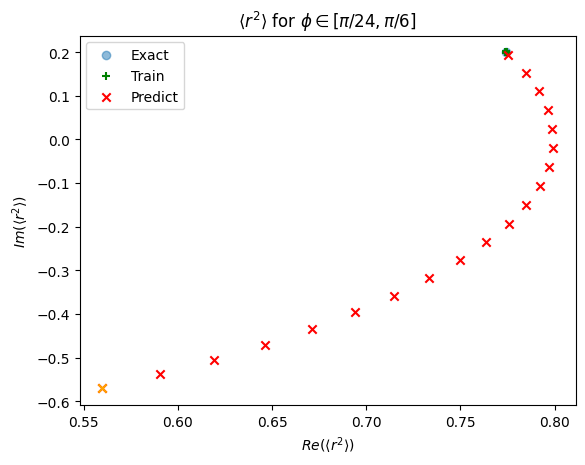

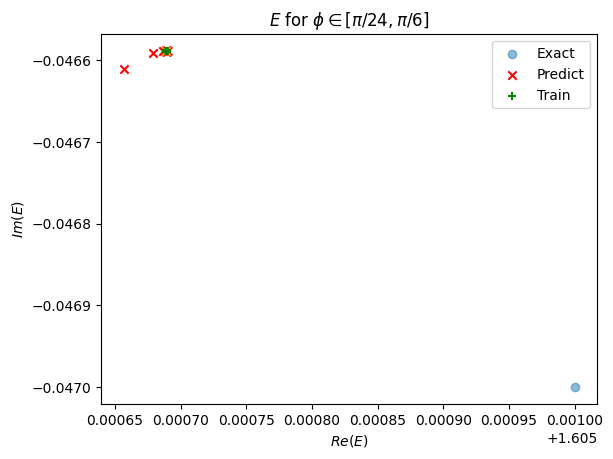

In [4]:
# plot rrs as phi changes
fig, ax = plt.subplots()
ax.scatter(np.real(exact_rr), np.imag(exact_rr), alpha=0.5, label="Exact")
ax.scatter(np.real(train_rrs), np.imag(train_rrs), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_rrs), np.imag(predict_rrs), c='red', marker='x', label="Predict")
ax.scatter(np.real(predict_rrs[-1]), np.imag(predict_rrs[-1]), c='orange', marker='x')
ax.set_xlabel(r"$Re(\langle r^2\rangle)$")
ax.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax.legend()
ax.set_title(r"$\langle r^2\rangle$ for $\phi\in [\pi/24,\pi/6]$")
if save_plots:
    plt.savefig(plots_folder / "ec_radius_defaultrr.png")
plt.show()

fig, ax = plt.subplots()
ax.scatter(np.real(real_res), np.imag(real_res), alpha=0.5, label="Exact")
ax.scatter(np.real(predict_energies), np.imag(predict_energies), c='red', marker='x', label="Predict")
ax.scatter(np.real(predict_energies[-1]), np.imag(predict_energies[-1]), c='orange', marker='x')
ax.scatter(np.real(train_energies), np.imag(train_energies), c='green', marker='+', label="Train")
ax.set_xlabel(r"$Re(E)$")
ax.set_ylabel(r"$Im(E)$")
ax.legend()
ax.set_title(r"$E$ for $\phi\in [\pi/24,\pi/6]$")
plt.show()

## Back-rotation as a function of the number of EC training points + stats
EC trained on eigenvectors of CS Hamiltonian at a rotation angle range $\phi\in [\pi/24, \pi/6]$.
$\langle r^2 \rangle$ and energy predicted at $\phi=0$.
We plot the median and quartile predictions of 128 EC systems trained on random points in the range above for 3, 5, 10, 20, 40, and 50 training points. 

In [5]:
import random

In [6]:
seed = 1

random.seed(seed)
np.random.seed(seed)

In [7]:
n_ecsystems = 128
# all other parameters already defined above

In [8]:
# exact_energy, exact_rr already computed above

# compute training data
phi_training_range, num_phi_points_list = [pi/24, pi/4], [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]

# get training region for plotting purposes
test_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
train_energies, train_rrs = [], []
for phi in np.linspace(phi_training_range[0], phi_training_range[1], 25):
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_rr(eigstate[:, 0], rotate_rr=True)
    train_energies.append(eigval[0])
    train_rrs.append(rr)

In [9]:
# construct EC ensemble and train all ECs
EC_ensemble = ECEnsemble(n_ecsystems, test_system, real_res)
predict_energies_stats, predict_rrs_stats = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training with {num_phi_points}")
    EC_ensemble.train(phi_training_range, num_phi_points)
    EC_ensemble.construct_bases()

    # predict at phi=0.0
    energies_stats, rrs_stats = EC_ensemble.predict_energies_rrs_wstats(0.0, rotate_rr=False)

    predict_energies_stats.append(energies_stats)
    predict_rrs_stats.append(rrs_stats)
    
    EC_ensemble.clear_all()

Training with 3
Training with 5
Training with 10
Training with 15
Training with 20
Training with 25
Training with 30
Training with 35
Training with 40
Training with 45
Training with 50
Training with 75


In [10]:
def decompose_stats(stats):
    median = [stat[0] for stat in stats]
    err68 = [stat[1] for stat in stats]
    err95 = [stat[2] for stat in stats]
    return np.array(median), np.array(err68), np.array(err95)

energy_med, energy_err68, energy_err95 = decompose_stats(predict_energies_stats)
rrs_med, rrs_err68, rrs_err95 = decompose_stats(predict_rrs_stats)
        

for i, num_phi in enumerate(num_phi_points_list):
    print(f"Data for {num_phi} training points:")

    print(f"<r^2> = ({np.real(rrs_med[i]):.4f} +- {np.max(np.abs(np.real(rrs_err95[i,:]))):.4f})"
          f"({np.imag(rrs_med[i]):.4f} +- {np.max(np.abs(np.imag(rrs_err95[i,:]))):.4f})")

    print(f"E = ({np.real(energy_med[i]):.4f} +- {np.max(np.abs(np.real(energy_err95[i,:]))):.4f})"
          f"i({np.imag(energy_med[i]):.4f} +- {np.max(np.abs(np.imag(energy_err95[i,:]))):.4f})")

Data for 3 training points:
<r^2> = (0.2026 +- 2.3558)(0.0789 +- 2.1265)
E = (1.5445 +- 0.7499)i(-0.0843 +- 1.0914)
Data for 5 training points:
<r^2> = (0.8126 +- 2.3714)(0.0960 +- 2.5668)
E = (1.6057 +- 0.2403)i(-0.0462 +- 0.5700)
Data for 10 training points:
<r^2> = (0.8403 +- 1.1200)(0.1791 +- 0.7202)
E = (1.6053 +- 0.0196)i(-0.0460 +- 0.0365)
Data for 15 training points:
<r^2> = (0.8118 +- 0.3710)(0.1614 +- 0.2604)
E = (1.6054 +- 0.0055)i(-0.0463 +- 0.0030)
Data for 20 training points:
<r^2> = (0.7994 +- 0.4705)(0.1504 +- 0.2585)
E = (1.6056 +- 0.0072)i(-0.0463 +- 0.0059)
Data for 25 training points:
<r^2> = (0.8007 +- 0.2004)(0.1579 +- 0.1721)
E = (1.6056 +- 0.0015)i(-0.0464 +- 0.0018)
Data for 30 training points:
<r^2> = (0.8091 +- 0.2598)(0.1556 +- 0.2191)
E = (1.6056 +- 0.0013)i(-0.0464 +- 0.0007)
Data for 35 training points:
<r^2> = (0.8057 +- 0.1424)(0.1600 +- 0.1416)
E = (1.6056 +- 0.0006)i(-0.0464 +- 0.0007)
Data for 40 training points:
<r^2> = (0.8095 +- 0.1809)(0.1562 +- 

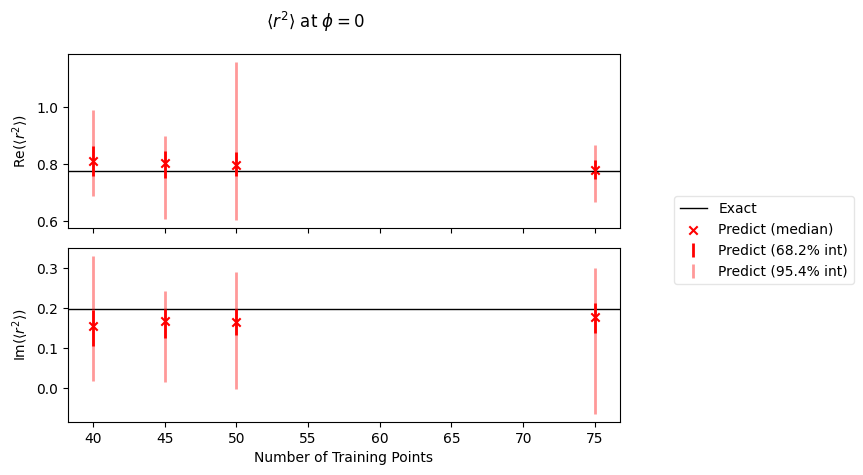

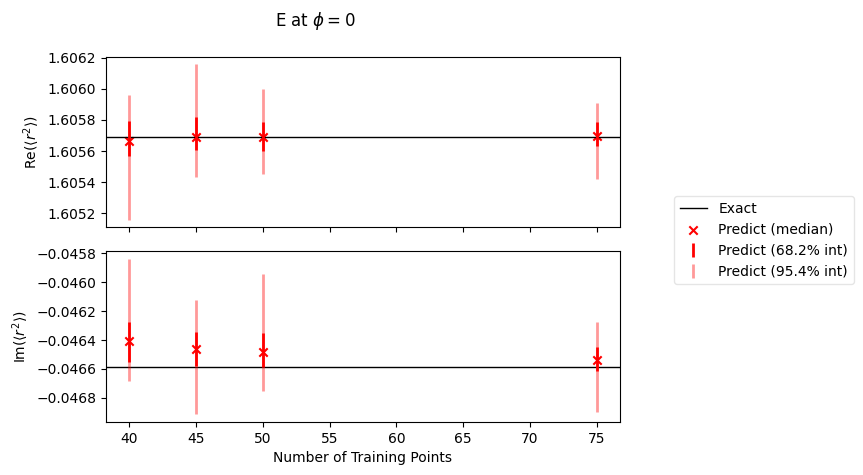

In [15]:
def plot_stats(fig, axs, xs, med, err68, err95, cutoff: int=0):
    ax1, ax2 = axs
    xs, med, err68, err95 = xs[cutoff:], med[cutoff:], err68[cutoff:, :], err95[cutoff:, :]
    # real component 
    ax1.scatter(xs, np.real(med), c='red', marker='x', label='Predict (median)')
    ax1.errorbar(xs, np.real(med),
             yerr=np.real(err68.T),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
    ax1.errorbar(xs, np.real(med),
             yerr=np.real(err95.T),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
    # imag component
    ax2.scatter(xs, np.imag(med), c='red', marker='x', label='Predict (median)')
    ax2.errorbar(xs, np.imag(med),
             yerr=np.imag(err68.T),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
    ax2.errorbar(xs, np.imag(med),
             yerr=np.imag(err95.T),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
    

# RADIUS PLOT
# plot results with error bands
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.axhline(y=np.real(exact_rr), color='black', linewidth=1.0, linestyle='-', label='Exact')
ax2.axhline(y=np.imag(exact_rr), color='black', linewidth=1.0, linestyle='-', label='Exact')
plot_stats(fig, (ax1, ax2), num_phi_points_list, rrs_med, rrs_err68, rrs_err95) 
#ax1.axhspan(ymin=np.min(np.real(train_rrs)), ymax=np.max(np.real(train_rrs)), color='gray', alpha=1.0, label='Train')
#ax2.axhspan(ymin=np.min(np.imag(train_rrs)), ymax=np.max(np.imag(train_rrs)), color='gray', alpha=1.0) 
ax1.set_ylabel(r"Re($\langle r^2\rangle)$")
ax2.set_ylabel(r"Im($\langle r^2\rangle)$")
ax2.set_xlabel("Number of Training Points")
fig.suptitle(r"$\langle r^2 \rangle$ at $\phi=0$")

# set legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), framealpha=0.5)
ax1.legend().remove()
ax2.legend().remove()
plt.tight_layout()
if save_plots:
    plt.savefig(plots_folder / "ec_radius_defaultrr_vartrainstats.png")
plt.show()

#------------------------------------------------------------------------------------------------------
# ENERGY PLOT
# plot results with error bands
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.axhline(y=np.real(exact_energy), color='black', linewidth=1.0, linestyle='-', label='Exact')
ax2.axhline(y=np.imag(exact_energy), color='black', linewidth=1.0, linestyle='-', label='Exact')
plot_stats(fig, (ax1, ax2), num_phi_points_list, energy_med, energy_err68, energy_err95)
#ax1.axhspan(ymin=np.min(np.real(train_energies)), ymax=np.max(np.real(train_energies)), color='gray', alpha=1.0, label='Train')
#ax2.axhspan(ymin=np.min(np.imag(train_energies)), ymax=np.max(np.imag(train_energies)), color='gray', alpha=1.) 
ax1.set_ylabel(r"Re($E)$")
ax2.set_ylabel(r"Im($E)$")
ax2.set_xlabel("Number of Training Points")
fig.suptitle(r"E at $\phi=0$")

# set legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), framealpha=0.5)
ax1.legend().remove()
ax2.legend().remove()
plt.tight_layout()
if save_plots:
    plt.savefig(plots_folder / "ec_E_vartrainstats.png")
plt.show()

In [29]:
# plot residual plot
def compute_residuals(exact, data):
    diff = data - exact
    data_resid = np.abs(np.real(diff)) + 1j*np.abs(np.imag(diff))
    return data_resid

energy_med_resids = compute_residuals(exact_energy, energy_med)
rrs_med_resids = compute_residuals(exact_rr, rrs_med)

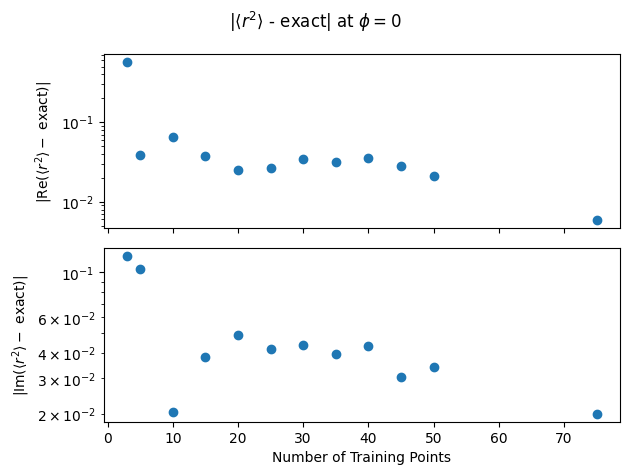

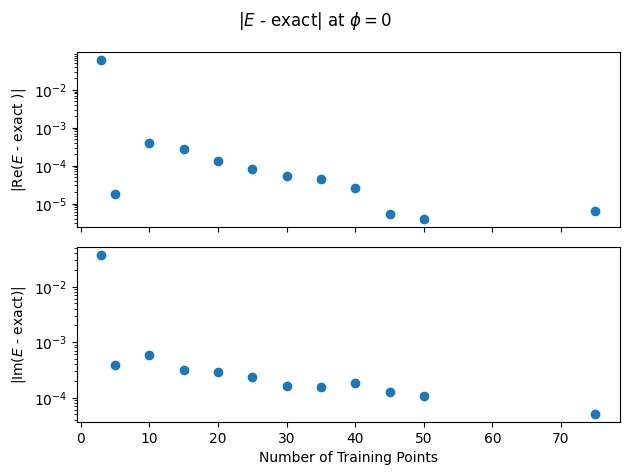

In [32]:
# radius residuals
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.scatter(num_phi_points_list, rrs_med_resids.real)
ax2.scatter(num_phi_points_list, rrs_med_resids.imag)
ax1.set_ylabel(r"|Re($\langle r^2\rangle -$ exact)|")
ax2.set_ylabel(r"|Im($\langle r^2\rangle -$ exact)|")
ax2.set_xlabel("Number of Training Points")
ax2.set_yscale("log")
ax1.set_yscale("log")
fig.suptitle(r"$|\langle r^2 \rangle$ - exact| at $\phi=0$")
plt.tight_layout()
plt.show()

#------------------------------------------------------------------------------------------------------
# ENERGY PLOT
# plot results with error bands
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.scatter(num_phi_points_list, energy_med_resids.real)
ax2.scatter(num_phi_points_list, energy_med_resids.imag)
ax1.set_ylabel(r"|Re($E$ - exact )|")
ax2.set_ylabel(r"|Im($E$ - exact)|")
ax2.set_xlabel("Number of Training Points")
ax2.set_yscale("log")
ax1.set_yscale("log")
fig.suptitle(r"|$E$ - exact| at $\phi=0$")
plt.tight_layout()
plt.show()